In [9]:
import pandas as pd
import sqlalchemy
import yaml
import matplotlib.pyplot as plt

with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

eng = sqlalchemy.create_engine(config['database']['connection_string'])

--- Daily Summary Data ---


,event_timestamp,event_count,significant_events
35,2026-04-22-01,10,0
36,2026-04-22-02,7,0
37,2026-04-22-03,10,0
38,2026-04-22-04,7,0
39,2026-04-22-05,4,0


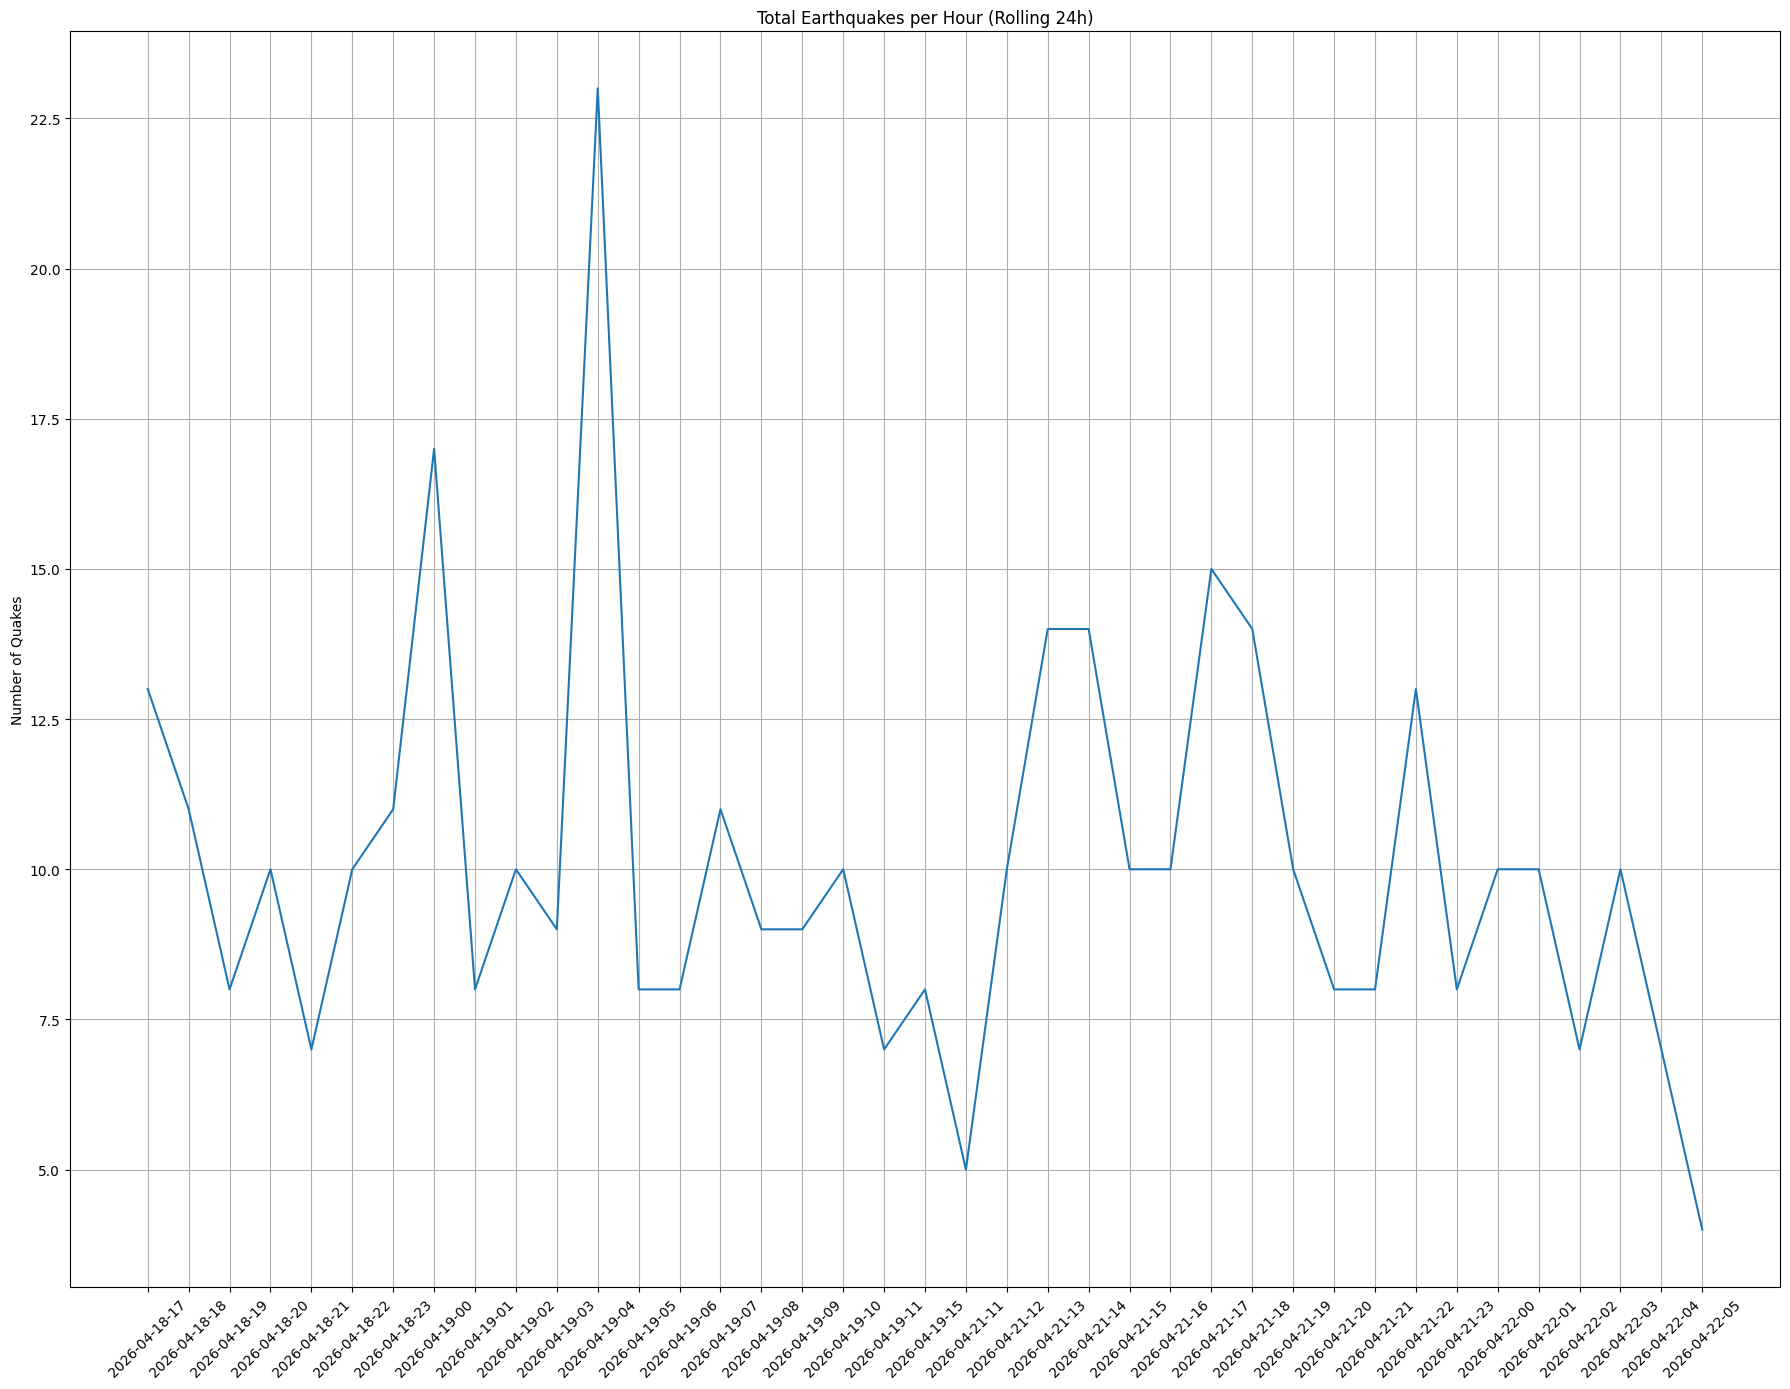

In [ ]:
query_daily = """
    SELECT event_timestamp, event_count, significant_events 
    FROM gold_daily_event_summary 
    ORDER BY event_timestamp ASC;
"""

df_daily = pd.read_sql(query_daily, eng)

print("--- Daily Summary Data ---")
display(df_daily.tail())
plt.figure(figsize=(18,14))          
plt.plot(df_daily['event_timestamp'], df_daily['event_count'])
plt.title("Total Earthquakes per Hour (Rolling 24h)")
plt.xticks(rotation=45)

plt.ylabel("Number of Quakes")
plt.grid(True)

plt.show()

--- Magnitude Distribution Data ---


,band,event_count
0,2-4,2
1,<2,6
2,2-4,51
3,4-6,14
4,<2,142
5,2-4,34
6,4-6,9
7,<2,144


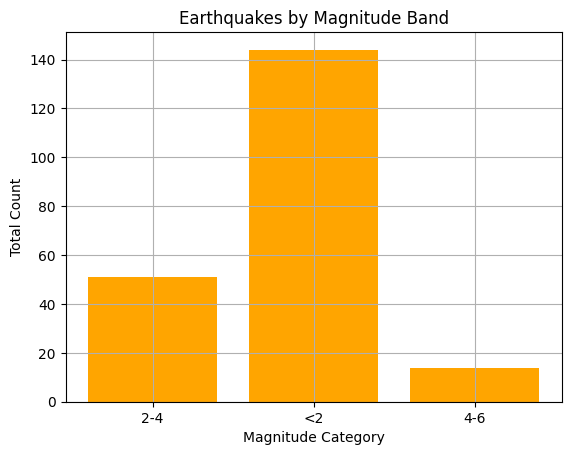

In [21]:
query_bands = """
    SELECT band, event_count 
    FROM gold_magnitude_distribution;
"""

df_bands = pd.read_sql(query_bands, eng)

print("--- Magnitude Distribution Data ---")
display(df_bands)


plt.bar(df_bands['band'].astype(str), df_bands['event_count'], color='orange')
plt.title("Earthquakes by Magnitude Band")

plt.xlabel("Magnitude Category")
plt.ylabel("Total Count")
plt.grid(True)
plt.show()

In [7]:
query_region = """
    SELECT country, event_count, avg_magnitude, max_magnitude
    FROM gold_region_activity
    ORDER BY event_count DESC
    LIMIT 10;
"""

df_region = pd.read_sql(query_region, eng)

print("--- Top 10 Most Active Regions ---")
display(df_region)

--- Top 10 Most Active Regions ---


,country,event_count,avg_magnitude,max_magnitude
0,US,173,1.501098,3.90
1,CA,11,1.745455,2.00
2,US,8,1.387500,2.20
3,TO,5,4.840000,5.40
4,PR,4,2.482500,2.87
5,VG,4,3.357500,3.90
6,ID,2,5.000000,5.70
7,EC,1,4.200000,4.20
8,GR,1,4.800000,4.80
9,IR,1,4.700000,4.70
